Categorías encontradas: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Cargando 403 imágenes de cardboard...
Cargando 501 imágenes de glass...
Cargando 410 imágenes de metal...
Cargando 594 imágenes de paper...
Cargando 482 imágenes de plastic...
Cargando 137 imágenes de trash...
------------------------------
ESTADO DE LAS VARIABLES:
Variable X (Entradas): (2527, 128, 128, 3)  -> [Muestras, Alto, Ancho, Canales]
Variable y (Salidas):  (2527,)  -> [Muestras,] con valores de 0 a 5
------------------------------


C:\Users\victo\AppData\Local\Temp\ipykernel_11432\2727929384.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nombres_clases, y=counts, palette='viridis')


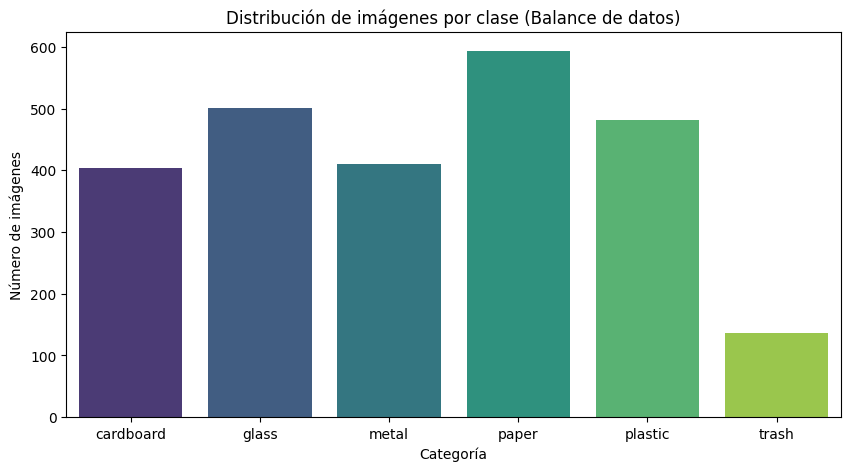

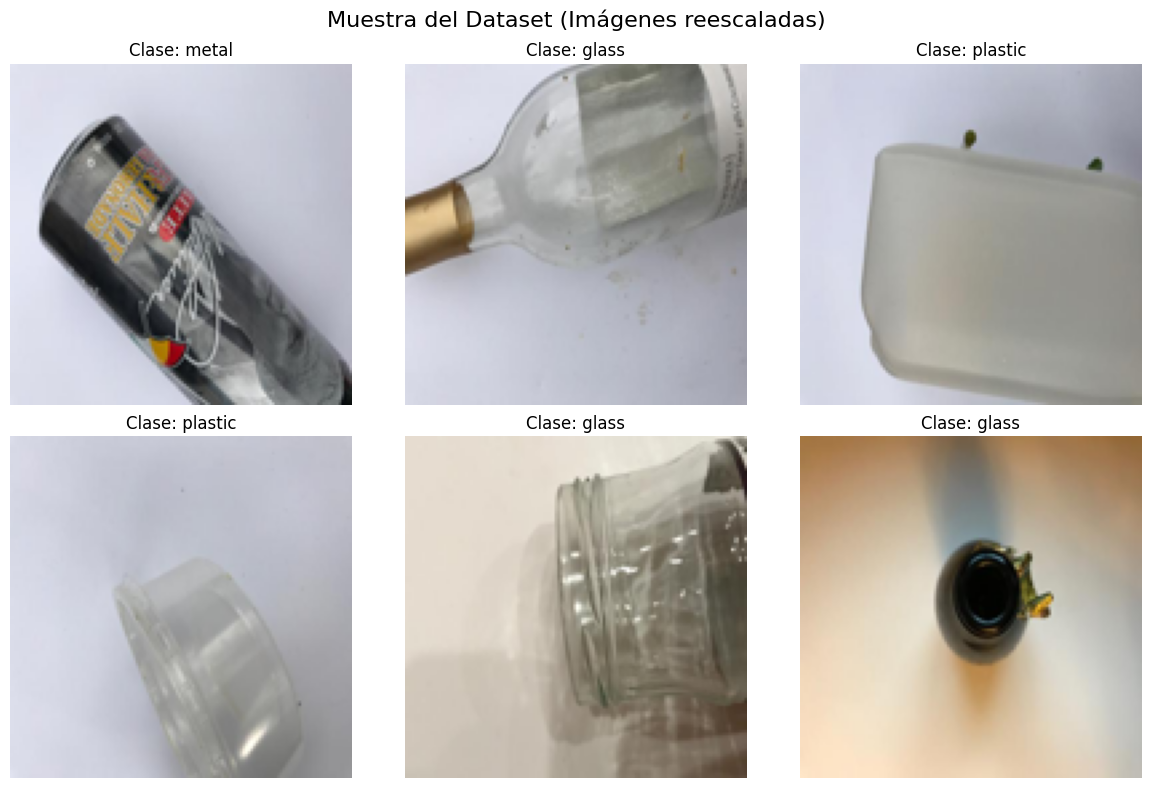

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import glob

# 1. CONFIGURACIÓN Y CARGA DE DATOS
PATH_DATOS = 'data/' 
IMG_SIZE = (128, 128) # Tamaño estándar para el reescalado

def preparar_datos(path):
    X_list = []
    y_list = []
    # Obtenemos las categorías basadas en los nombres de las carpetas
    categorias = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])
    
    print(f"Categorías encontradas: {categorias}")
    
    for idx, cat in enumerate(categorias):
        files = glob.glob(os.path.join(path, cat, '*'))
        print(f"Cargando {len(files)} imágenes de {cat}...")
        for f in files:
            try:
                # Abrir, convertir a RGB (por si hay BN o RGBA) y reescalar
                img = Image.open(f).convert('RGB')
                img = img.resize(IMG_SIZE)
                X_list.append(np.array(img))
                y_list.append(idx)
            except Exception as e:
                print(f"Error cargando archivo {f}: {e}")
                
    return np.array(X_list), np.array(y_list), categorias

# Ejecutamos la carga (Creando las variables X, y)
X, y, nombres_clases = preparar_datos(PATH_DATOS)

print("-" * 30)
print(f"ESTADO DE LAS VARIABLES:")
print(f"Variable X (Entradas): {X.shape}  -> [Muestras, Alto, Ancho, Canales]")
print(f"Variable y (Salidas):  {y.shape}  -> [Muestras,] con valores de 0 a {len(nombres_clases)-1}")
print("-" * 30)

# 2. EDA (ANÁLISIS EXPLORATORIO DE DATOS)

# Cantidad de datos y balance de clases
plt.figure(figsize=(10, 5))
counts = [np.sum(y == i) for i in range(len(nombres_clases))]
sns.barplot(x=nombres_clases, y=counts, palette='viridis')
plt.title("Distribución de imágenes por clase (Balance de datos)")
plt.ylabel("Número de imágenes")
plt.xlabel("Categoría")
plt.show()

# Visualización de ejemplos aleatorios
plt.figure(figsize=(12, 8))
for i in range(6):
    idx = np.random.randint(0, len(X))
    plt.subplot(2, 3, i+1)
    plt.imshow(X[idx])
    plt.title(f"Clase: {nombres_clases[y[idx]]}")
    plt.axis('off')
plt.suptitle("Muestra del Dataset (Imágenes reescaladas)", fontsize=16)
plt.tight_layout()
plt.show()


